# Unified Multi-Output Weather Model (ESP32)

This notebook trains a single Dense (MLP) model to predict next-day precipitation and evapotranspiration from the expanded weather dataset.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
sns.set_theme(style='whitegrid')


I0000 00:00:1777843348.662669  978995 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Load Dataset

In [2]:
df = pd.read_csv('historical_weather_data.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
print(f'Loaded {len(df)} daily weather rows.')

Loaded 1461 daily weather rows.


## 3. Feature Relationships

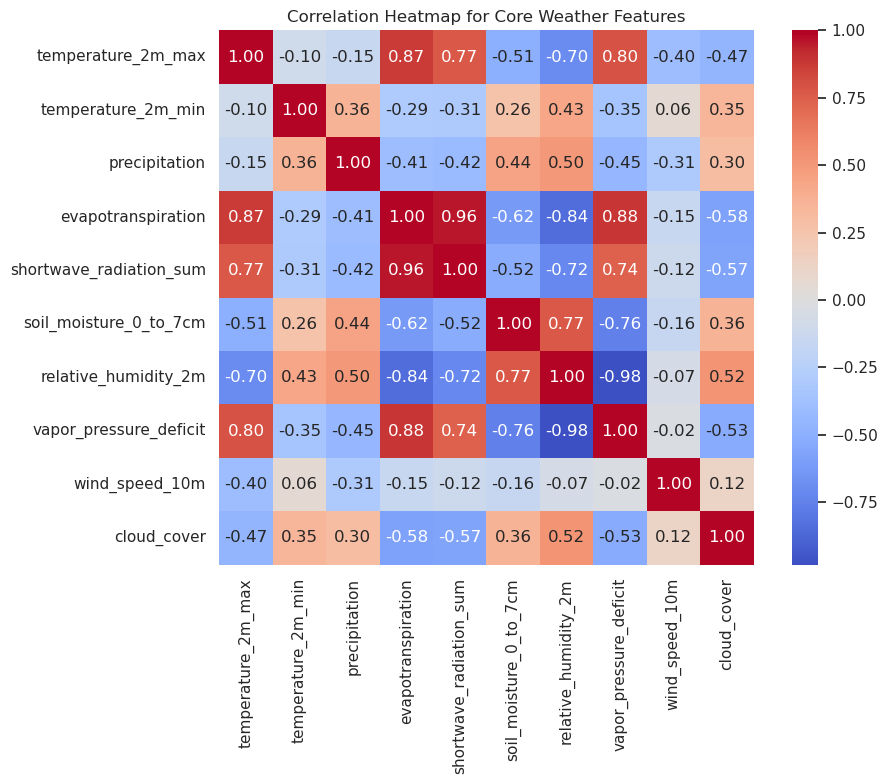

In [3]:
eda_cols = [
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation',
    'evapotranspiration',
    'shortwave_radiation_sum',
    'soil_moisture_0_to_7cm',
    'relative_humidity_2m',
    'vapor_pressure_deficit',
    'wind_speed_10m',
    'cloud_cover',
]
eda_cols = [col for col in eda_cols if col in df.columns]

corr = df[eda_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap for Core Weather Features')
plt.tight_layout()
plt.show()


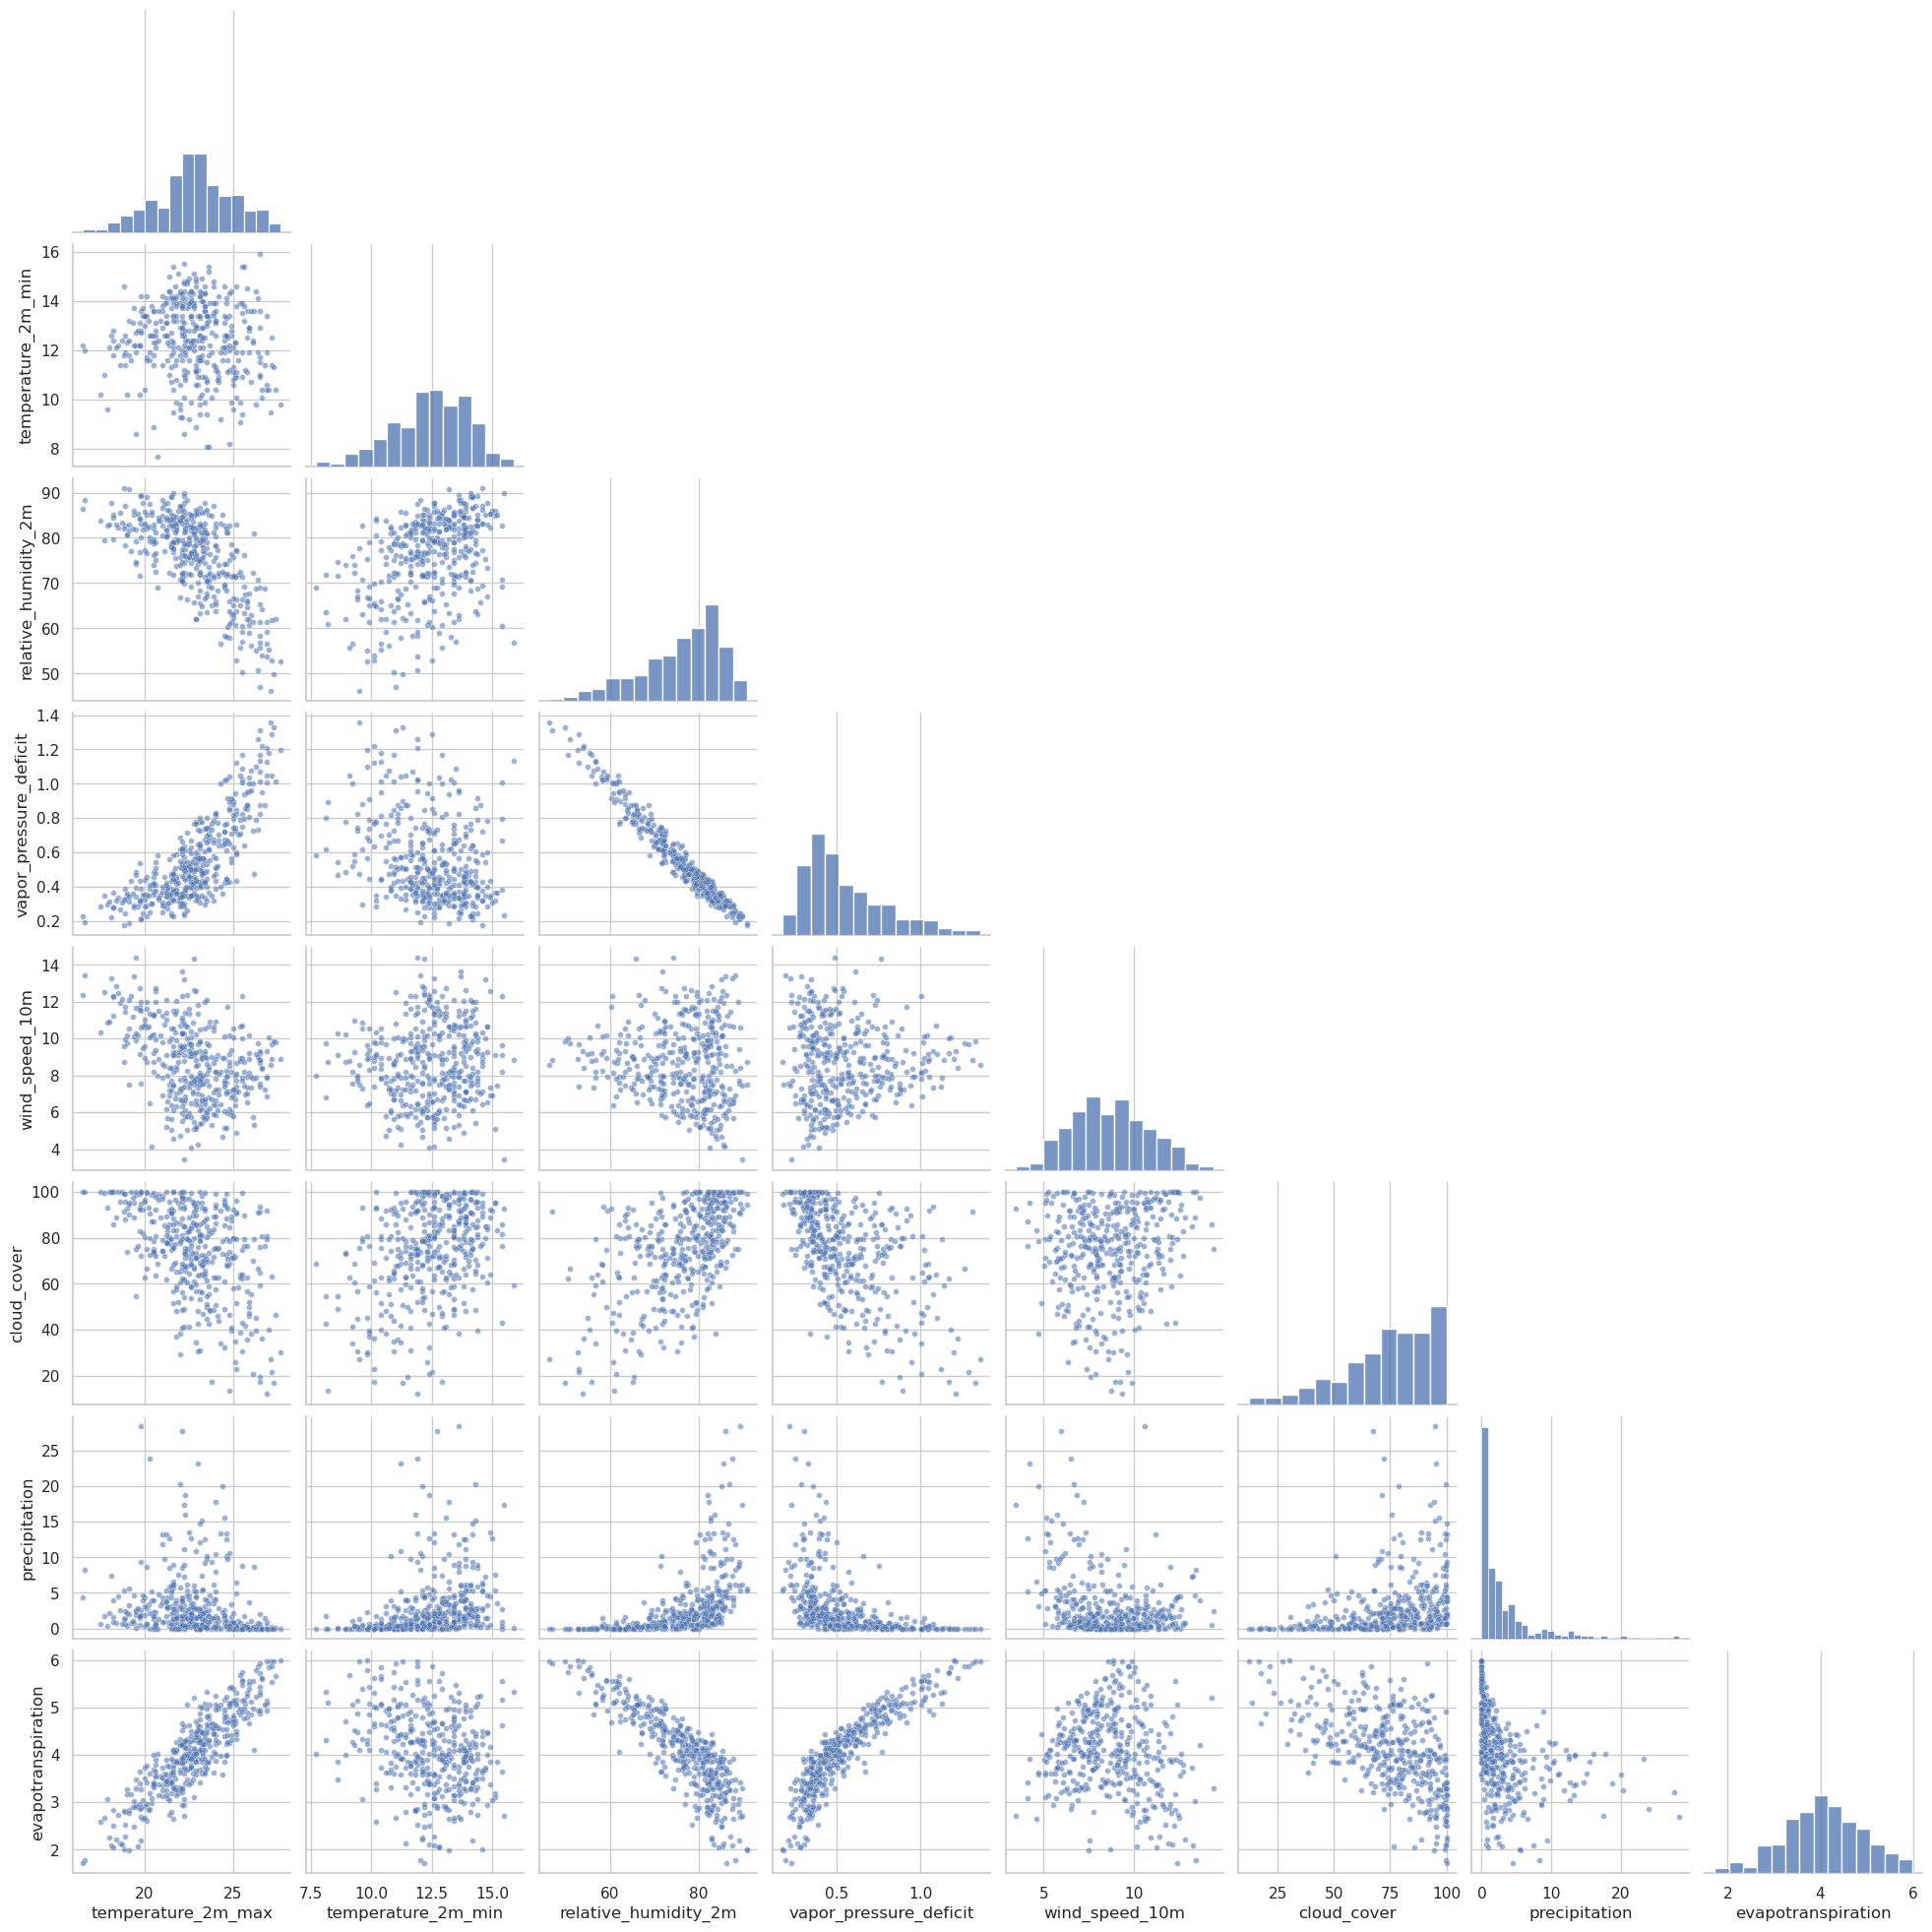

In [4]:
pairplot_cols = [
    'temperature_2m_max',
    'temperature_2m_min',
    'relative_humidity_2m',
    'vapor_pressure_deficit',
    'wind_speed_10m',
    'cloud_cover',
    'precipitation',
    'evapotranspiration',
]
pairplot_cols = [col for col in pairplot_cols if col in df.columns]

# Downsample rows so the pairplot remains readable in the notebook.
pairplot_df = df[pairplot_cols].sample(n=min(len(df), 400), random_state=42)
sns.pairplot(pairplot_df, corner=True, diag_kind='hist', plot_kws={'alpha': 0.55, 's': 18})
plt.show()


## 4. Feature Engineering

In [5]:
weather_cols = [
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation',
    'evapotranspiration',
    'shortwave_radiation_sum',
    'soil_moisture_0_to_7cm',
    'relative_humidity_2m',
    'vapor_pressure_deficit',
    'wind_speed_10m',
    'cloud_cover',
]
weather_cols = [col for col in weather_cols if col in df.columns]

lag_days = range(1, 8)
# Include current-day signals alongside lagged and rolling history.
feature_cols = weather_cols.copy()

df['temperature_range'] = df['temperature_2m_max'] - df['temperature_2m_min']
df['humidity_vpd_product'] = df['relative_humidity_2m'] * df['vapor_pressure_deficit']
df['soil_humidity_product'] = df['soil_moisture_0_to_7cm'] * df['relative_humidity_2m']
df['radiation_vpd_product'] = df['shortwave_radiation_sum'] * df['vapor_pressure_deficit']
feature_cols.extend([
    'temperature_range',
    'humidity_vpd_product',
    'soil_humidity_product',
    'radiation_vpd_product',
])
if 'cloud_cover' in df.columns:
    df['cloud_radiation_product'] = df['cloud_cover'] * df['shortwave_radiation_sum']
    feature_cols.append('cloud_radiation_product')

for col in weather_cols:
    for lag in lag_days:
        feature_name = f'{col}_lag_{lag}'
        df[feature_name] = df[col].shift(lag)
        feature_cols.append(feature_name)
    for window in (3, 7):
        feature_name = f'{col}_roll_{window}'
        df[feature_name] = df[col].shift(1).rolling(window).mean()
        feature_cols.append(feature_name)

day_of_year = df['time'].dt.dayofyear
df['day_of_year_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
feature_cols.extend(['day_of_year_sin', 'day_of_year_cos'])

df['target_precipitation'] = df['precipitation'].shift(-1)
df['target_evapotranspiration'] = df['evapotranspiration'].shift(-1)
df = df.dropna().reset_index(drop=True)

X = df[feature_cols].to_numpy(dtype=np.float32)
# Log-scaling stabilizes the more skewed precipitation target.
y = np.column_stack([
    np.log1p(df['target_precipitation'].to_numpy(dtype=np.float32)),
    df['target_evapotranspiration'].to_numpy(dtype=np.float32),
]).astype(np.float32)

print(f'Feature count: {len(feature_cols)}')
print(f'Input shape: {X.shape}')
print(f'Target shape: {y.shape}')

Feature count: 107
Input shape: (1453, 107)
Target shape: (1453, 2)


## 5. Train/Test Split & Scaling

In [6]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std[X_std == 0] = 1e-6

y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)
y_std[y_std == 0] = 1e-6

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std
y_train_scaled = (y_train - y_mean) / y_std

np.save('X_mean_unified.npy', X_mean)
np.save('X_std_unified.npy', X_std)
np.save('y_mean_unified.npy', y_mean)
np.save('y_std_unified.npy', y_std)

print(f'Training rows: {len(X_train)}')
print(f'Testing rows: {len(X_test)}')

Training rows: 1162
Testing rows: 291


## 6. Unified MLP Architecture

In [7]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.15),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,226 (94.63 KB)

 Trainable params: 24,226 (94.63 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train Model

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5),
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    verbose=0,
    callbacks=callbacks,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

Training stopped after 24 epochs.
Best val_loss: 0.5542


## 8. Performance Evaluation

In [9]:
pred_scaled = model.predict(X_test_scaled, verbose=0)
pred = (pred_scaled * y_std) + y_mean

pred_precip = np.expm1(pred[:, 0]).clip(min=0)
pred_evapotranspiration = pred[:, 1]

y_test_precip = np.expm1(y_test[:, 0])
y_test_evapotranspiration = y_test[:, 1]

mae_p = mean_absolute_error(y_test_precip, pred_precip)
r2_p = r2_score(y_test_precip, pred_precip)

mae_e = mean_absolute_error(y_test_evapotranspiration, pred_evapotranspiration)
r2_e = r2_score(y_test_evapotranspiration, pred_evapotranspiration)

print('========== PRECIPITATION (Unified) ==========')
print(f'MAE: {mae_p:.3f} mm  | R²: {r2_p:.3f}')
print('\n========== EVAPOTRANSPIRATION (Unified) ==========')
print(f'MAE: {mae_e:.3f} mm  | R²: {r2_e:.3f}')

========== PRECIPITATION (Unified) ==========
MAE: 2.476 mm  | R²: 0.039

========== EVAPOTRANSPIRATION (Unified) ==========
MAE: 0.431 mm  | R²: 0.388


## 9. Export to TFLite

In [10]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('unified_weather_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f'Saved unified_weather_model.tflite ({len(tflite_model)} bytes)')

INFO:tensorflow:Assets written to: /tmp/tmpy0qjd_zx/assets


INFO:tensorflow:Assets written to: /tmp/tmpy0qjd_zx/assets


Saved artifact at '/tmp/tmpy0qjd_zx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 107), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140503180060240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140503180304976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140503176884016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140503176884496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140503176887856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140503180113104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140503180108304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140503180111424: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1777843359.352454  978995 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777843359.352468  978995 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Saved unified_weather_model.tflite (30296 bytes)


I0000 00:00:1777843359.352733  978995 reader.cc:83] Reading SavedModel from: /tmp/tmpy0qjd_zx
I0000 00:00:1777843359.353331  978995 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1777843359.353341  978995 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpy0qjd_zx
I0000 00:00:1777843359.357603  978995 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1777843359.358306  978995 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1777843359.383918  978995 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpy0qjd_zx
I0000 00:00:1777843359.394199  978995 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 41472 microseconds.
I0000 00:00:1777843359.407653  978995 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


## 10. Generate C Array

In [11]:
def convert_tflite_to_c_array(tflite_path, c_file_path, array_name):
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()

    hex_array = [f'0x{b:02x}' for b in tflite_content]

    with open(c_file_path, 'w') as f:
        f.write(f'#include "{array_name}.h"\n\n')
        f.write(f'const unsigned char {array_name}[] = {{\n')
        for i in range(0, len(hex_array), 12):
            f.write('  ' + ', '.join(hex_array[i:i + 12]) + ',\n')
        f.write('};\n\n')
        f.write(f'const int {array_name}_len = {len(hex_array)};\n')

    h_file_path = c_file_path.replace('.cc', '.h')
    with open(h_file_path, 'w') as f:
        f.write(f'#ifndef {array_name.upper()}_H\n')
        f.write(f'#define {array_name.upper()}_H\n\n')
        f.write(f'extern const unsigned char {array_name}[];\n')
        f.write(f'extern const int {array_name}_len;\n\n')
        f.write(f'#endif // {array_name.upper()}_H\n')

    print(f'Generated {c_file_path} and {h_file_path}')

convert_tflite_to_c_array(
    'unified_weather_model.tflite',
    'unified_weather_model.cc',
    'unified_weather_model_tflite',
)

Generated unified_weather_model.cc and unified_weather_model.h
